In [117]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName('my spark app for users') \
    .config('spark.some.config.option' , 'somev-alue') \
    .getOrCreate()


print(spark)

In [118]:
df = spark.read.csv('person_data.csv' , header=True , inferSchema=True)

In [119]:
df.show()

+---------+----------+---------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId|  Surname|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+---------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|        1|  15634602| Hargrave|        619|   France|Female| 42|     2|      0.0|            1|        1|             1|      101348.88|     1|
|        2|  15647311|     Hill|        608|    Spain|Female| 41|     1| 83807.86|            1|        0|             1|      112542.58|     0|
|        3|  15619304|     Onio|        502|   France|Female| 42|     8| 159660.8|            3|        1|             0|      113931.57|     1|
|        4|  15701354|     Boni|        699|   France|Female| 39|     1|      0.0|            2|        0|             0|       93

In [120]:
df.printSchema()

root
 |-- RowNumber: integer (nullable = true)
 |-- CustomerId: integer (nullable = true)
 |-- Surname: string (nullable = true)
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)



In [121]:
df.describe().show()

+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|summary|         RowNumber|       CustomerId|Surname|      CreditScore|Geography|Gender|               Age|            Tenure|          Balance|     NumOfProducts|          HasCrCard|     IsActiveMember|  EstimatedSalary|             Exited|
+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|  count|             10000|            10000|  10000|            10000|    10000| 10000|             10000|             10000|            10000|             10000|              10000|              10000|            10000|              10000|
|   mean|            5000.5|

In [122]:
from pyspark.sql.functions import col, sum, trim

numeric_values = [c for c , type  in df.dtypes if type in ['int' , 'float' , 'double' , 'short'  , 'decimal' ]]

numeric_values

df_null_counts = df.select([
    sum(
        (

            col(c) == 0
          
            
        ).cast("int")
    ).alias(c)
    for c in numeric_values
])

df_null_counts.show()


+---------+----------+-----------+---+------+-------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId|CreditScore|Age|Tenure|Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+-----------+---+------+-------+-------------+---------+--------------+---------------+------+
|        0|         0|          0|  0|   413|   3617|            0|     2945|          4849|              0|  7963|
+---------+----------+-----------+---+------+-------+-------------+---------+--------------+---------------+------+



In [123]:
numeric_cols = [c for c, dtype in df.dtypes 
                if dtype in ('int', 'long', 'float', 'double', 'short', 'decimal')]

probabilities = [0.25, 0.5, 0.75]
relative_error = 0.25

quantiles_list = df.approxQuantile(numeric_cols, probabilities, relative_error)


print("Approximate Quantiles (25%, 50%, 75%):")
for col_name, values in zip(numeric_cols, quantiles_list):
    print(f"Column '{col_name}': {values}")

Approximate Quantiles (25%, 50%, 75%):
Column 'RowNumber': [1.0, 2502.0, 10000.0]
Column 'CustomerId': [15565701.0, 15628558.0, 15815690.0]
Column 'CreditScore': [350.0, 584.0, 850.0]
Column 'Age': [18.0, 32.0, 92.0]
Column 'Tenure': [0.0, 3.0, 10.0]
Column 'Balance': [0.0, 0.0, 250898.09]
Column 'NumOfProducts': [1.0, 1.0, 4.0]
Column 'HasCrCard': [0.0, 0.0, 1.0]
Column 'IsActiveMember': [0.0, 0.0, 1.0]
Column 'EstimatedSalary': [11.58, 51016.02, 199992.48]
Column 'Exited': [0.0, 0.0, 1.0]


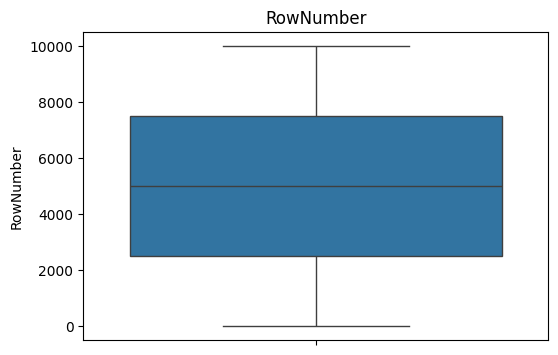

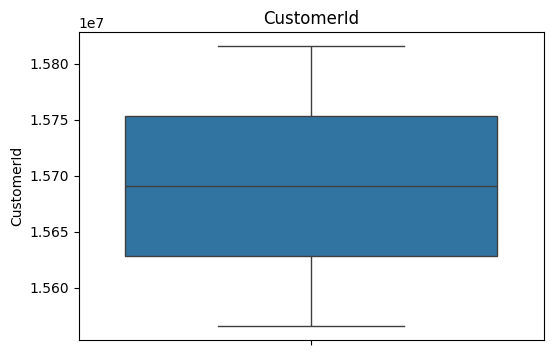

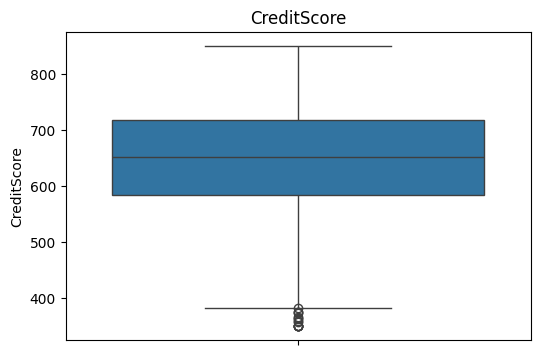

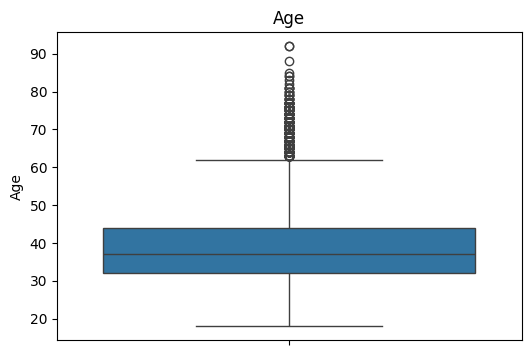

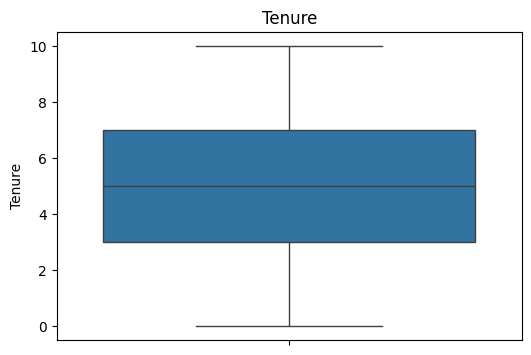

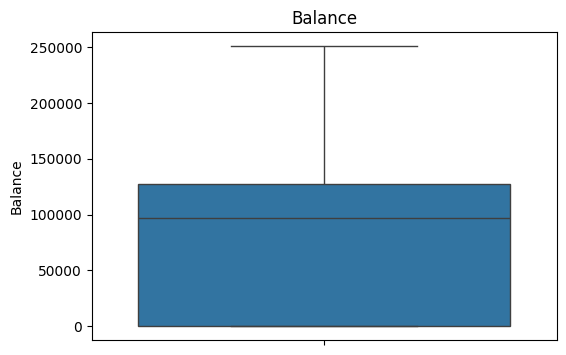

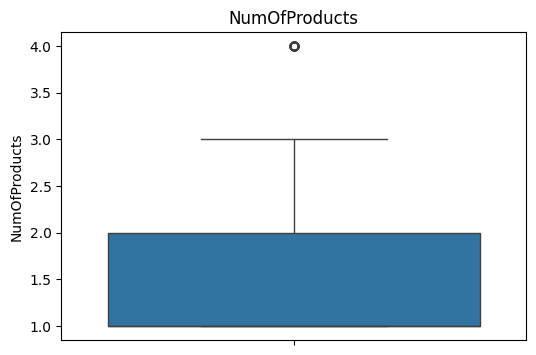

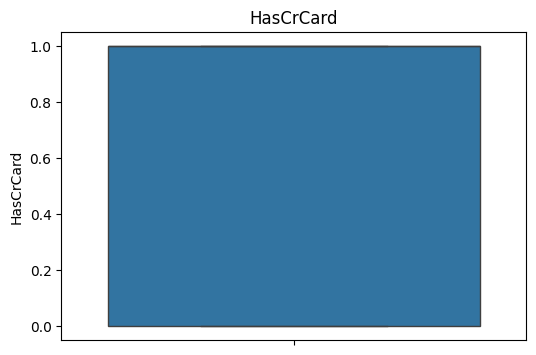

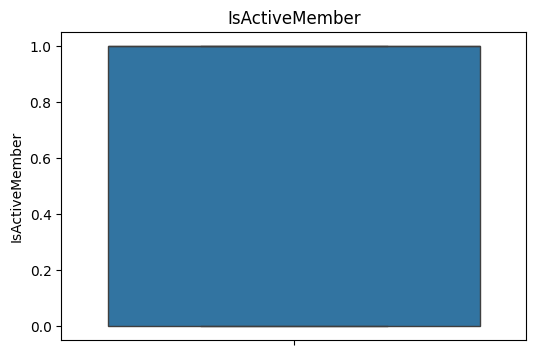

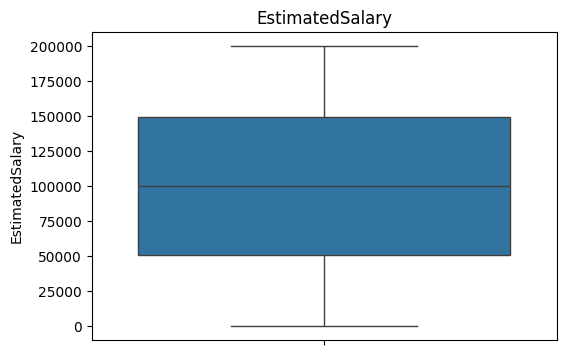

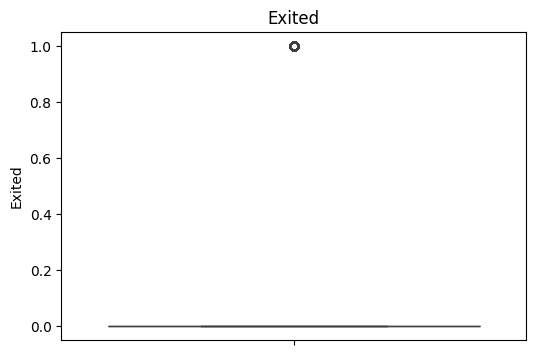

In [124]:
import seaborn as sns 
import matplotlib.pyplot as plt

df_numeric = df.select(numeric_cols).toPandas()


for c in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df_numeric[c])
    plt.title(c)
    plt.show()



In [125]:
path = "person_data.csv"
df = spark.read.csv(path, header=True, inferSchema=True)
df.printSchema()
df.show(10, truncate=False)
print("Exited distribution:")
df.groupBy('Exited').count().show()
numeric_cols = [c for c, t in df.dtypes if t in ('int','long','float','double','decimal','short')]
print(numeric_cols)

root
 |-- RowNumber: integer (nullable = true)
 |-- CustomerId: integer (nullable = true)
 |-- Surname: string (nullable = true)
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)

+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId|Surname |CreditScore|Geography|Gender|Age|Tenure|Balance  |NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+----

In [126]:
manual_drop = ["RowNumber","CustomerId","Surname"]
keep_cols = {"Exited","Balance","EstimatedSalary","CreditScore","Age","Tenure","NumOfProducts","HasCrCard","IsActiveMember","Geography","Gender"}
existing_manual = [c for c in manual_drop if c in df.columns]
from pyspark.sql import functions as F
n_rows = df.count()
unique_threshold = 0.95
auto_drop = []
for c in df.columns:
    if c in keep_cols or c in existing_manual:
        continue
    distinct = df.select(F.countDistinct(F.col(c))).collect()[0][0]
    if n_rows > 0 and distinct / float(n_rows) > unique_threshold:
        auto_drop.append(c)
final_drop = [c for c in set(existing_manual + auto_drop) if c not in keep_cols]
print(existing_manual)
print(auto_drop)
print(final_drop)
df_clean = df.drop(*final_drop) if final_drop else df
df_clean.printSchema()
df_clean.show(10, truncate=False)
dropped_columns = final_drop

['RowNumber', 'CustomerId', 'Surname']
[]
['Surname', 'RowNumber', 'CustomerId']
root
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)

+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|CreditScore|Geography|Gender|Age|Tenure|Balance  |NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|619        |France   |Female|42 |2     |0.0      |1            |1        |1             |101348.88      |1     |

In [127]:
probabilities=[0.25,0.5,0.75]
relative_error=0.01
if numeric_cols:
    quantiles = df.approxQuantile(numeric_cols, probabilities, relative_error)
    for col_name,q in zip(numeric_cols,quantiles):
        print(col_name, q)
else:
    print("no numeric columns")

RowNumber [2496.0, 4943.0, 7408.0]
CustomerId [15628303.0, 15689412.0, 15750929.0]
CreditScore [584.0, 651.0, 714.0]
Age [32.0, 37.0, 44.0]
Tenure [2.0, 5.0, 7.0]
Balance [0.0, 96402.96, 126615.94]
NumOfProducts [1.0, 1.0, 2.0]
HasCrCard [0.0, 1.0, 1.0]
IsActiveMember [0.0, 1.0, 1.0]
EstimatedSalary [50906.65, 98897.32, 147342.03]
Exited [0.0, 0.0, 0.0]


In [128]:
print(f"Dataset rows before processing: {df.count()}")
print("Exited distribution:")
df.groupBy('Exited').count().show()

Dataset rows before processing: 10000
Exited distribution:
+------+-----+
|Exited|count|
+------+-----+
|     1| 2037|
|     0| 7963|
+------+-----+

+------+-----+
|Exited|count|
+------+-----+
|     1| 2037|
|     0| 7963|
+------+-----+



In [129]:
new_df = df.drop(*["CustomerId","Surname"])
new_df.show(5)

+---------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|        1|        619|   France|Female| 42|     2|      0.0|            1|        1|             1|      101348.88|     1|
|        2|        608|    Spain|Female| 41|     1| 83807.86|            1|        0|             1|      112542.58|     0|
|        3|        502|   France|Female| 42|     8| 159660.8|            3|        1|             0|      113931.57|     1|
|        4|        699|   France|Female| 39|     1|      0.0|            2|        0|             0|       93826.63|     0|
|        5|        850|    Spain|Female| 43|     2|125510.82|            1|        1|             1|        79084.1|     0|
+-------

In [130]:
df_pandas = df.toPandas()
df_pandas

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [131]:
list_dict = df_pandas.to_dict("records")

In [132]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017")
collection = client["ma_base_de_donnees"]["client_data"]

In [133]:
try:
    result = collection.insert_many(list_dict)
except Exception as e:
    print(e)

In [134]:
collection.count_documents({})

33031

In [135]:
data_list = list(collection.find({}))
data_list

[{'_id': ObjectId('690f5ca6f3a85a7ef234a5e0'),
  'RowNumber': 2,
  'CustomerId': 15647311,
  'Surname': 'Hill',
  'CreditScore': 608,
  'Geography': 'Spain',
  'Gender': 'Female',
  'Age': 41,
  'Tenure': 1,
  'Balance': 83807.86,
  'NumOfProducts': 1,
  'HasCrCard': 0,
  'IsActiveMember': 1,
  'EstimatedSalary': 112542.58,
  'Exited': 0},
 {'_id': ObjectId('690f5ca6f3a85a7ef234a5e1'),
  'RowNumber': 4,
  'CustomerId': 15701354,
  'Surname': 'Boni',
  'CreditScore': 699,
  'Geography': 'France',
  'Gender': 'Female',
  'Age': 39,
  'Tenure': 1,
  'Balance': 0.0,
  'NumOfProducts': 2,
  'HasCrCard': 0,
  'IsActiveMember': 0,
  'EstimatedSalary': 93826.63,
  'Exited': 0},
 {'_id': ObjectId('690f5ca6f3a85a7ef234a5e2'),
  'RowNumber': 5,
  'CustomerId': 15737888,
  'Surname': 'Mitchell',
  'CreditScore': 850,
  'Geography': 'Spain',
  'Gender': 'Female',
  'Age': 43,
  'Tenure': 2,
  'Balance': 125510.82,
  'NumOfProducts': 1,
  'HasCrCard': 1,
  'IsActiveMember': 1,
  'EstimatedSalary': 7

In [136]:
print(f"Total rows in df: {df.count()}")
print(f"Exited value counts:")
df.groupBy('Exited').count().show()

majority_class = df.filter(df.Exited == 0)
minority_class = df.filter(df.Exited == 1)
print(f"Majority class (0) count: {majority_class.count()}")
print(f"Minority class (1) count: {minority_class.count()}")

majority_downsampled = majority_class.sample(withReplacement=False, fraction=minority_class.count() / majority_class.count(), seed=42)
print(f"Downsampled majority: {majority_downsampled.count()}")

df_balanced = majority_downsampled.union(minority_class)
print(f"Balanced dataset size: {df_balanced.count()}")
df_balanced.groupBy('Exited').count().show()

Total rows in df: 10000
Exited value counts:
+------+-----+
|Exited|count|
+------+-----+
|     1| 2037|
|     0| 7963|
+------+-----+

Majority class (0) count: 7963
Minority class (1) count: 2037
Majority class (0) count: 7963
Minority class (1) count: 2037
Downsampled majority: 2119
Balanced dataset size: 4156
Downsampled majority: 2119
Balanced dataset size: 4156
+------+-----+
|Exited|count|
+------+-----+
|     0| 2119|
|     1| 2037|
+------+-----+

+------+-----+
|Exited|count|
+------+-----+
|     0| 2119|
|     1| 2037|
+------+-----+



In [137]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [c for c, t in df_balanced.dtypes if c != 'Exited' and t in ('int', 'long', 'float', 'double', 'decimal', 'short')]
df_balanced_clean = df_balanced.dropna(subset=feature_cols)
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df_assembled = assembler.transform(df_balanced_clean)
df_assembled.select('features', 'Exited').show(5)

+--------------------+------+
|            features|Exited|
+--------------------+------+
|[12.0,1.5737173E7...|     0|
|[22.0,1.5597945E7...|     0|
|[25.0,1.5625047E7...|     0|
|[34.0,1.5659428E7...|     0|
|[35.0,1.5732963E7...|     0|
+--------------------+------+
only showing top 5 rows


In [138]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol='features', outputCol='scaled_features')
df_scaled = scaler.fit(df_assembled).transform(df_assembled)
df_scaled.select('scaled_features', 'Exited').show(5)

+--------------------+------+
|     scaled_features|Exited|
+--------------------+------+
|[0.00415944097776...|     0|
|[0.00762564179256...|     0|
|[0.00866550203700...|     0|
|[0.01178508277032...|     0|
|[0.01213170285180...|     0|
+--------------------+------+
only showing top 5 rows


In [139]:
train_df, test_df = df_scaled.randomSplit([0.8, 0.2], seed=42)
print(f"Train rows: {train_df.count()}, Test rows: {test_df.count()}")

Train rows: 3379, Test rows: 777


In [140]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol='Exited', featuresCol='scaled_features', maxIter=100)
lr_model = lr.fit(train_df)
predictions = lr_model.transform(test_df)
predictions.select('prediction', 'Exited').show(10)

+----------+------+
|prediction|Exited|
+----------+------+
|       0.0|     0|
|       0.0|     0|
|       1.0|     0|
|       0.0|     0|
|       0.0|     0|
|       0.0|     0|
|       1.0|     0|
|       1.0|     0|
|       0.0|     0|
|       0.0|     0|
+----------+------+
only showing top 10 rows


In [142]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.classification import LogisticRegression

scaler_pipe = StandardScaler(inputCol='features', outputCol='scaled_features')
lr_pipe = LogisticRegression(labelCol='Exited', featuresCol='scaled_features', maxIter=100)
pipeline = Pipeline(stages=[scaler_pipe, lr_pipe])
pipeline_model = pipeline.fit(df_assembled)
pipeline_predictions = pipeline_model.transform(df_assembled)
pipeline_predictions.select('prediction', 'Exited').show(10)

+----------+------+
|prediction|Exited|
+----------+------+
|       0.0|     0|
|       0.0|     0|
|       0.0|     0|
|       0.0|     0|
|       0.0|     0|
|       0.0|     0|
|       0.0|     0|
|       1.0|     0|
|       1.0|     0|
|       0.0|     0|
+----------+------+
only showing top 10 rows


In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression

lr_cv = LogisticRegression(labelCol='Exited', featuresCol='scaled_features', maxIter=100)
param_grid = ParamGridBuilder() \
    .addGrid(lr_cv.regParam, [0.01, 0.1, 1.0]) \
    .addGrid(lr_cv.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

evaluator = BinaryClassificationEvaluator(labelCol='Exited', rawPredictionCol='rawPrediction')

cv = CrossValidator(estimator=lr_cv, estimatorParamMaps=param_grid, evaluator=evaluator, numFolds=3)
cv_model = cv.fit(train_df)
cv_predictions = cv_model.transform(test_df)
cv_predictions.select('prediction', 'Exited').show(10)

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator as BCE

predictions_final = cv_model.transform(test_df)

auc_evaluator = BCE(labelCol='Exited', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
auc = auc_evaluator.evaluate(predictions_final)

accuracy_evaluator = MulticlassClassificationEvaluator(labelCol='Exited', predictionCol='prediction', metricName='accuracy')
accuracy = accuracy_evaluator.evaluate(predictions_final)

precision_evaluator = MulticlassClassificationEvaluator(labelCol='Exited', predictionCol='prediction', metricName='weightedPrecision')
precision = precision_evaluator.evaluate(predictions_final)

recall_evaluator = MulticlassClassificationEvaluator(labelCol='Exited', predictionCol='prediction', metricName='weightedRecall')
recall = recall_evaluator.evaluate(predictions_final)

f1_evaluator = MulticlassClassificationEvaluator(labelCol='Exited', predictionCol='prediction', metricName='f1')
f1 = f1_evaluator.evaluate(predictions_final)

print(f"AUC: {auc}, Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")

In [ ]:
from pyspark.sql.functions import col

tp = predictions_final.filter((col('prediction') == 1) & (col('Exited') == 1)).count()
tn = predictions_final.filter((col('prediction') == 0) & (col('Exited') == 0)).count()
fp = predictions_final.filter((col('prediction') == 1) & (col('Exited') == 0)).count()
fn = predictions_final.filter((col('prediction') == 0) & (col('Exited') == 1)).count()

print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

In [ ]:
cv_model.write().overwrite().save('/tmp/final_model')